Implement a linear upsampling of two fm's features, later fused by abundance estimator

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np
from tqdm import tqdm
import gc

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"

sys.path.append(f"{global_path}/SS-HSU_benchmark")
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils, losses, plots, extractor
from src.models import models
from src.models import foundation_models as rsfm
from src.models import unmixers as unmx

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [ ]:
class UnmixingFrom3FMs(nn.Module):
    def __init__(self, D, B, c, alpha_dofa, alpha_specaware, alpha_specvit, H=224):
        """
        Upsamples low res features from DOFA + SpecAware then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFrom3FMs, self).__init__()
        self.D = D
        self.alpha_dofa = alpha_dofa
        self.alpha_specaware = alpha_specaware
        self.alpha_specvit = alpha_specvit
        self.B = B
        self.c = c
        self.H = H

        # Upsampling features
        self.upsample_dofa = nn.Linear(self.alpha_dofa**2, self.H**2, bias=False)
        self.upsample_specvit = nn.Linear(self.alpha_specvit**2, self.H**2, bias=False)
        self.upsample_specaware = nn.Linear(self.alpha_specaware**2, self.H**2, bias=False)
  
        # Upsampled features to abundances
        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(D, c, kernel_size=1, bias=False),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(0.2)
        )

        self.smooth = nn.Sequential(
            nn.Conv2d(c, c, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.Softmax(dim=1),
        )

        self.sum_to_one = rsfm.Sum_to_one()
        self.decoder = rsfm.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, features_hr=None, features_lr=None, channel_selector=None, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_tv_a=0, W_mse=0.09, W_e=0, W_feat=0, W_tv_feat=0, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Feature regularisation"""

        if features_hr != None:
            l1 = nn.L1Loss()
            downsample = nn.AdaptiveAvgPool2d(features_lr[0].shape)
            features_down = downsample(features_hr)

            loss_features = W_feat * l1(utils.normalise(features_down), utils.normalise(features_lr))
        
        else:
            loss_features = 0

        loss = loss_sad + loss_ab + loss_mse + loss_features

        if channel_selector != None:
            loss += torch.linalg.norm(channel_selector, dim=0, ord=1)#/ len(channel_selector)

        if return_losses:
            return loss, loss_sad, loss_ab, loss_mse
        else:
            return loss

    def get_abundances(self, features_dofa, features_specaware, features_specvit):

        features_up_dofa = utils.oneD_to_2d(self.upsample_dofa(features_dofa)).unsqueeze(0)
        features_up_specaware = utils.oneD_to_2d(self.upsample_specaware(features_specaware)).unsqueeze(0)
        features_up_specvit = utils.oneD_to_2d(self.upsample_specvit(features_specvit)).unsqueeze(0)

        features_up = torch.cat((features_up_dofa, features_up_specaware, features_up_specvit), dim=1)
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        # A_hat = self.smooth(A_hat)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features_dofa, features_specaware, features_specvit):
        A_hat = self.get_abundances(features_dofa, features_specaware, features_specvit)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

In [ ]:
class UnmixingFrom2FMs(nn.Module):
    def __init__(self, D, B, c, alpha_dofa, alpha_specaware):
        """
        Upsamples low res features from DOFA + SpecAware then estimates A_hat
        
        Args:
            D (int): The embed_dim
            B (int): The number of spectral bands in the hsi
            c (int): The number of endmembers to extract
            H (int): The size of the input hsi
            alpha (int): The size of the features
            n_features (int): The size of the list of features in the case of several extracted features

        """
        super(UnmixingFrom2FMs, self).__init__()
        self.D = D
        self.alpha_dofa = alpha_dofa
        self.alpha_specaware = alpha_specaware
        self.B = B
        self.c = c
        self.H = 224

        # Upsampling features
        self.upsample_dofa = nn.Linear(self.alpha_dofa**2, self.H**2, bias=False)
        self.upsample_specaware = nn.Linear(self.alpha_specaware**2, self.H**2, bias=False)
  
        # Upsampled features to abundances
        self.abundance_estimator = nn.Sequential(
            nn.Conv2d(D, c, kernel_size=1, bias=False),
            nn.LeakyReLU(0.02),
            nn.BatchNorm2d(c),
            nn.Dropout(0.2)
        )

        self.smooth = nn.Sequential(
            nn.Conv2d(c, c, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)),
            nn.Softmax(dim=1),
        )

        self.sum_to_one = rsfm.Sum_to_one()
        self.decoder = rsfm.Decoder(B=B, c=c)

    @staticmethod
    def weights_init(m):
        if type(m) == nn.Conv2d:
            nn.init.kaiming_normal_(m.weight.data)

    @staticmethod
    def loss(Y_gt, Y_hat, A_hat, E_hat, features_hr=None, features_lr=None, channel_selector=None, W_sad=1, W_ab=0.6, W_tv_e=3e-5, W_tv_a=0, W_mse=0.09, W_e=0, W_feat=0, W_tv_feat=0, hypersigma=False, return_losses=False):
        sad = losses.SADLoss()
        tv = losses.TVLoss(reduction="mean")
        mse = nn.MSELoss(reduction='sum')
        
        loss_sad = W_sad * sad(Y_gt, Y_hat)
        loss_ab = W_ab * torch.sqrt(A_hat).mean()

        if hypersigma:
            loss_mse = W_mse * losses.hypersigma_mse(Y_gt, Y_hat)
        else:
            loss_mse = W_mse * mse(Y_gt, Y_hat)/(torch.norm(Y_gt)**2)

        """Feature regularisation"""

        if features_hr != None:
            l1 = nn.L1Loss()
            downsample = nn.AdaptiveAvgPool2d(features_lr[0].shape)
            features_down = downsample(features_hr)

            loss_features = W_feat * l1(utils.normalise(features_down), utils.normalise(features_lr))
        
        else:
            loss_features = 0

        loss = loss_sad + loss_ab + loss_mse + loss_features

        if channel_selector != None:
            loss += torch.linalg.norm(channel_selector, dim=0, ord=1)#/ len(channel_selector)

        if return_losses:
            return loss, loss_sad, loss_ab, loss_mse
        else:
            return loss

    def get_abundances(self, features_dofa, features_specaware):

        features_up_dofa = utils.oneD_to_2d(self.upsample_dofa(features_dofa)).unsqueeze(0)
        features_up_specaware = utils.oneD_to_2d(self.upsample_specaware(features_specaware)).unsqueeze(0)

        features_up = torch.cat((features_up_dofa, features_up_specaware), dim=1)
        features_up = (features_up - features_up.mean())/ (1e-8 + features_up.std())
        A_hat = self.abundance_estimator(features_up)
        # A_hat = self.smooth(A_hat)
        A_hat = self.sum_to_one(A_hat)

        return A_hat
    
    def get_endmembers(self):
        return self.decoder.get_endmembers()
    
    def forward(self, features_dofa, features_specaware):
        A_hat = self.get_abundances(features_dofa, features_specaware)
        Y_hat = self.decoder(A_hat)
        E_hat = self.decoder.get_endmembers()

        return E_hat, A_hat, Y_hat

In [43]:
dataset = "urban"
data = io.loadmat(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
H = Y_init.shape[-1]
A_init = utils.oneD_to_2d(A_flat)
# Y_init = Y_init/Y_init.max()
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

n_xp = 10

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

dofa, Y_init_dofa, new_H = rsfm.create_fm("DOFA", Y_init, size="large", version="v1", path=global_path)
specaware, Y_init_specaware, _ = rsfm.create_fm("SpecAware", Y_init, path=global_path)
specvit, Y_init_specvit, new_H_specvit = rsfm.create_fm("SpecViT", Y_init, size="base", path=global_path)

_, features_dofa = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths)
_, features_specaware = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths)
_, features_specvit = rsfm.extract_f(specvit, Y_init_specvit, new_H_specvit, wavelengths)

D_dofa = int(features_dofa.shape[0])
alpha_dofa = int(features_dofa.shape[1]**0.5)
D_specaware = int(features_specaware.shape[0])
alpha_specaware = int(features_specaware.shape[1]**0.5)
D_specvit = int(features_specvit.shape[0])
alpha_specvit = int(features_specvit.shape[1]**0.5)

D = D_dofa + D_specaware + D_specvit

print(f"DOFA: {features_dofa.shape}")
print(f"SpecAware: {features_specaware.shape}")
print(f"SpecViT: {features_specvit.shape}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2285.85it/s]


DOFA: torch.Size([1024, 196])
SpecAware: torch.Size([768, 784])
SpecViT: torch.Size([768, 1024])


In [44]:
all_models = UnmixingFrom3FMs(D=D, alpha_dofa=alpha_dofa, alpha_specaware=alpha_specaware, alpha_specvit=alpha_specvit, H=new_H_specvit, B=B, c=c)
dofa_spawr = UnmixingFrom2FMs(D=D_dofa+D_specaware, alpha_dofa=alpha_dofa, alpha_specaware=alpha_specaware, B=B, c=c)
dofa_unmx = unmx.UnmixingFromFeatures(D=D_dofa, alpha=alpha_dofa, B=B, c=c)
specaware_unmx = unmx.UnmixingFromFeatures(D=D_specaware, alpha=alpha_specaware, B=B, c=c)
specvit_unmx = unmx.UnmixingFromFeatures(D=D_specvit, alpha=alpha_specvit, B=B, c=c, H=new_H_specvit)

print(f"All_models has {sum(p.numel() for p in all_models.parameters() if p.requires_grad)/1e6}M params")
print(f"DOFA+SpAwr has {sum(p.numel() for p in dofa_spawr.parameters() if p.requires_grad)/1e6}M params")
print(f"DOFA has {sum(p.numel() for p in dofa_unmx.parameters() if p.requires_grad)/1e6}M params")
print(f"SpcAwr has {sum(p.numel() for p in specaware_unmx.parameters() if p.requires_grad)/1e6}M params")
print(f"SpViT has {sum(p.numel() for p in specvit_unmx.parameters() if p.requires_grad)/1e6}M params")

All_models has 32.85021M params
DOFA+SpAwr has 49.184546M params
DOFA has 9.841954M params
SpcAwr has 39.343906M params
SpViT has 16.783138M params


### All 3 models

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.221, NMSE = 0.260
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.199, NMSE = 0.265
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.241, NMSE = 0.210
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.190, NMSE = 0.326
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.217, NMSE = 0.267
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.202, NMSE = 0.286
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.205, NMSE = 0.220

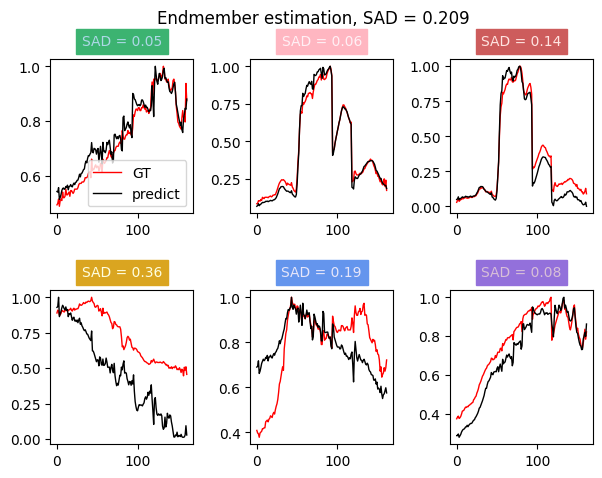

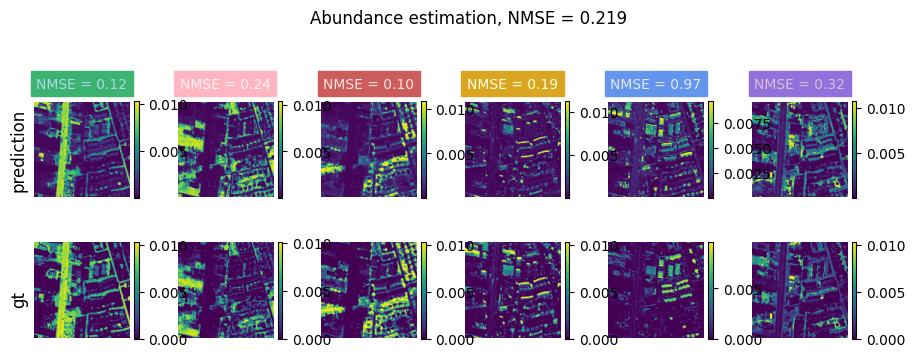

In [ ]:
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H_specvit, new_H_specvit)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H_specvit, new_H_specvit)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFrom3FMs(D=D, alpha_dofa=alpha_dofa, alpha_specaware=alpha_specaware, alpha_specvit=alpha_specvit, H=new_H_specvit, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_specaware/Y_init_specaware.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            _, features_dofa = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths)
            _, features_specaware = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths)
            Y_fm, features_specvit = rsfm.extract_f(specvit, Y_init_specvit, new_H_specvit, wavelengths)

            E_hat, A_hat, Y_hat = model(features_dofa, features_specaware, features_specvit)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, channel_selector=model.channel_selector)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                if hasattr(model, "channel_selector"):
                    model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        _, features_dofa = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths)
        _, features_specaware = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths)
        _, A_init_fm, features_specvit = rsfm.extract_f(specvit, Y_init_specvit, new_H_specvit, wavelengths, A_init)

        E_hat, A_hat, Y_hat = model(features_dofa, features_specaware, features_specvit)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
# plots.plot_pca_features(features)
plt.show()
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

### DOFA + SpecAware

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.152, NMSE = 0.169
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.164, NMSE = 0.169
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.215, NMSE = 0.174
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.156, NMSE = 0.179
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.195, NMSE = 0.171
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.189, NMSE = 0.170
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.157, NMSE = 0.166

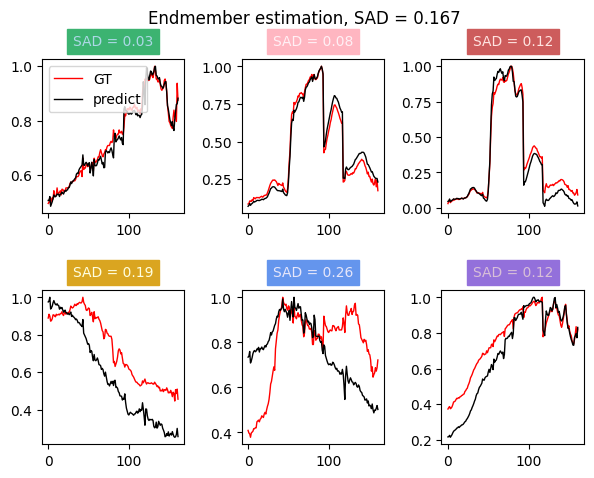

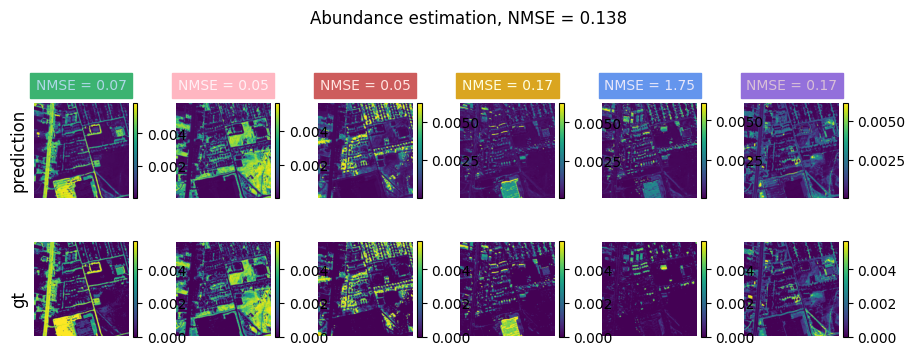

In [ ]:
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = UnmixingFrom2FMs(D=D_dofa+D_specaware, alpha_dofa=alpha_dofa, alpha_specaware=alpha_specaware, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_specaware/Y_init_specaware.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            _, features_dofa = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths)
            Y_fm, features_specaware = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths)

            E_hat, A_hat, Y_hat = model(features_dofa, features_specaware)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)#, channel_selector=model.channel_selector)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                if hasattr(model, "channel_selector"):
                    model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        _, features_dofa = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths)
        Y_fm, A_init_fm, features_specaware = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths, A_init)

        E_hat, A_hat, Y_hat = model(features_dofa, features_specaware)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
# plots.plot_pca_features(features)
plt.show()
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

### DOFA

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.184, NMSE = 0.169
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.180, NMSE = 0.197
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.191, NMSE = 0.182
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.122, NMSE = 0.252
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.200, NMSE = 0.198
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.168, NMSE = 0.184
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.206, NMSE = 0.219

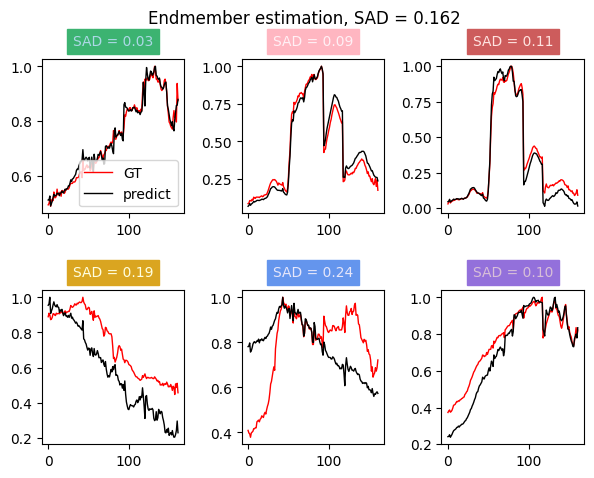

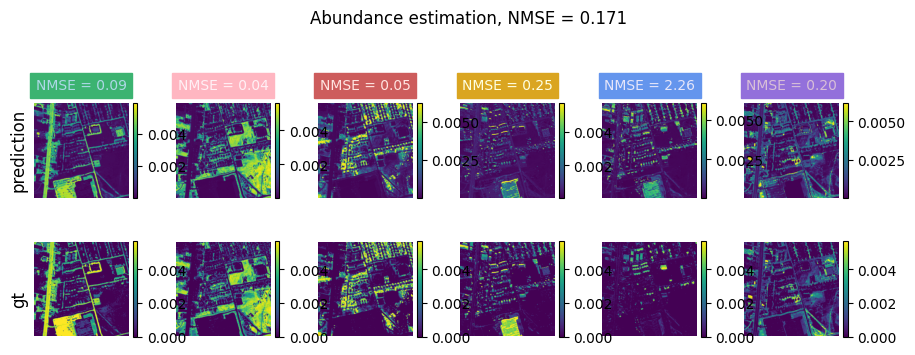

In [ ]:
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D_dofa, alpha=alpha_dofa, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_dofa/Y_init_dofa.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            Y_fm, features = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths)
            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                if hasattr(model, "channel_selector"):
                    model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        Y_fm, A_init_fm, features = rsfm.extract_f(dofa, Y_init_dofa, new_H, wavelengths, A_init)
        E_hat, A_hat, Y_hat = model(features, Y_fm)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
# plots.plot_pca_features(features)
plt.show()
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

### SpecAware

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.164, NMSE = 0.178
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.144, NMSE = 0.197
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.124, NMSE = 0.160
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.150, NMSE = 0.165
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.140, NMSE = 0.184
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.125, NMSE = 0.191
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.149, NMSE = 0.248

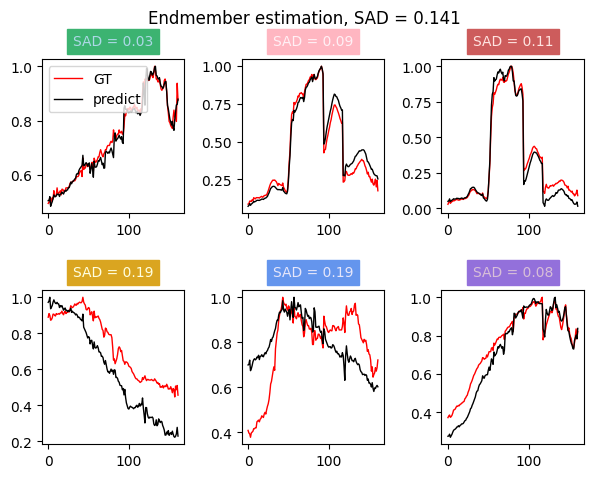

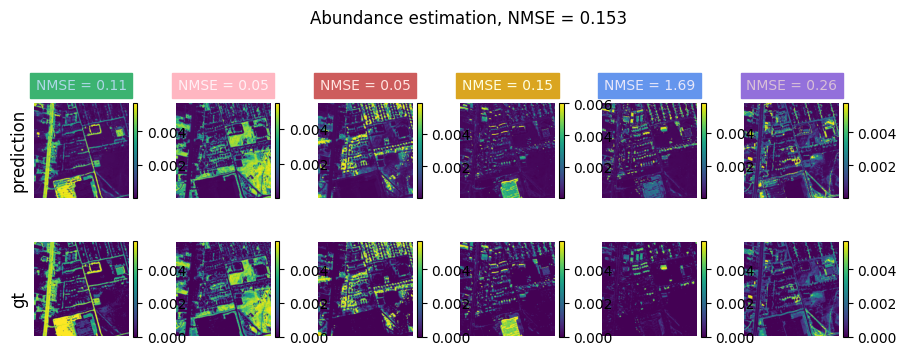

In [ ]:
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H, new_H)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D_specaware, alpha=alpha_specaware, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_specaware/Y_init_specaware.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            Y_fm, features = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths)
            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                if hasattr(model, "channel_selector"):
                    model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        Y_fm, A_init_fm, features = rsfm.extract_f(specaware, Y_init_specaware, new_H, wavelengths, A_init)
        E_hat, A_hat, Y_hat = model(features, Y_fm)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
# plots.plot_pca_features(features)
plt.show()
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")

### SpecViT

training 1/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.199, NMSE = 0.278
training 2/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.196, NMSE = 0.261
training 3/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.195, NMSE = 0.276
training 4/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.194, NMSE = 0.261
training 5/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.192, NMSE = 0.266
training 6/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.197, NMSE = 0.259
training 7/10
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Current SAD = 0.197, NMSE = 0.265

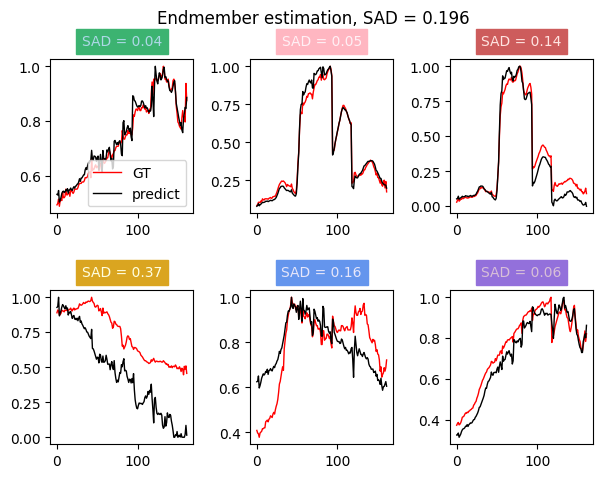

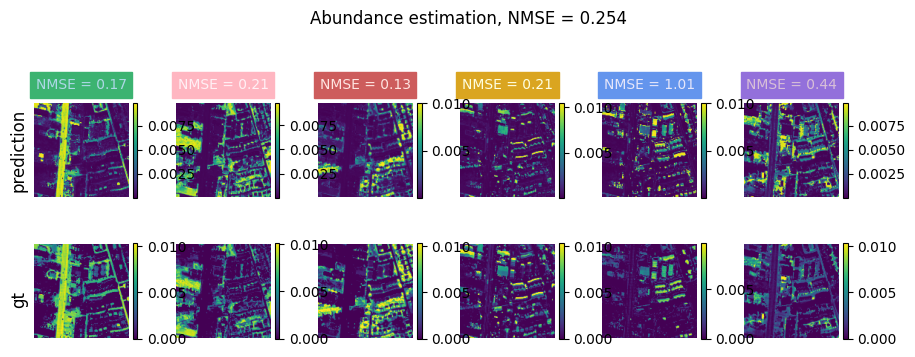

In [ ]:
mses, sads = [], []
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H_specvit, new_H_specvit)
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
upsampled_features = torch.zeros(n_xp, D, new_H_specvit, new_H_specvit)

for i in range(n_xp): 
    print(f"training {i+1}/{n_xp}")

    model = unmx.UnmixingFromFeatures(D=D_specvit, alpha=alpha_specvit, H=new_H_specvit, B=B, c=c)
    model.apply(model.weights_init)
    model = models.init_decoder_weights(model, Y_init_specvit/Y_init_specvit.max(), c, is_unmixer=True)

    epochs, lr = 200, 0.002
    optim_wrapper = dict(
        optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
        constructor='LayerDecayOptimizerConstructor_ViT',
        paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9, ))
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for _ in range(epochs):

        for Y, _, _ in loader:
        
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            # Y = Y/Y.max()

            Y_fm, features = rsfm.extract_f(specvit, Y_init_specvit, new_H_specvit, wavelengths)
            E_hat, A_hat, Y_hat = model(features, Y_fm)

            loss = model.loss(Y_fm, Y_hat, A_hat, E_hat)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()
            
            with torch.no_grad():
                constraints = models.weightConstraint()
                if hasattr(model, "channel_selector"):
                    model.channel_selector.data = model.channel_selector.data.clamp(0, 1)
                model.decoder.apply(constraints)
                
    model.eval()
    
    with torch.no_grad():

        Y_fm, A_init_fm, features = rsfm.extract_f(specvit, Y_init_specvit, new_H_specvit, wavelengths, A_init)
        E_hat, A_hat, Y_hat = model(features, Y_fm)
        
        sad, _, mse = plots.compute_metrics_and_plot(E_hat, A_hat, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True, plot_E=False, plot_A=False)
        print(f"Current SAD = {format(sad, '.3f')}, NMSE = {format(mse, '.3f')}")
        mses.append(mse)
        sads.append(sad)

    E_hats[i] = E_hat
    A_hats[i] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
# plots.plot_pca_features(features)
plt.show()
sad, _, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init_fm, E_init, normalise_E=True, normalise_A=True, return_results=True)
print(f"Model has {sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6}M params")
print(f"Average SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.3f')}, MSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.3f')}")